<div dir="rtl">

# 2. پاکسازی و آماد هسازی دادهها و تحلیل اکتشافی

</div>

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_csv('./covid_19.csv')
df = df.drop(columns=['id'],axis=1)

df.head()
df.shape

(566602, 22)

### Nan-values

In [354]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: [nan 'No' 'Yes']
pneumonia: ['No' 'Yes' nan]
pregnancy: [nan 'No' 'Yes']
diabetes: ['No' 'Yes' nan]
copd: ['No' 'Yes' nan]
asthma: ['No' 'Yes' nan]
inmsupr: ['No' 'Yes' nan]
hypertension: ['No' 'Yes' nan]
other_disease: ['No' 'Yes' nan]
cardiovascular: ['No' 'Yes' nan]
obesity: ['No' 'Yes' nan]
renal_chronic: ['No' 'Yes' nan]
tobacco: ['No' 'Yes' nan]
contact_other_covid: ['No' nan 'Yes']
covid_res: ['Positive' 'Negative' 'Not Yet Determined']
icu: [nan 'Not Admitted' 'Admitted']


In [355]:
df.loc[df['sex'] == 'male', 'pregnancy'] = "No"
df['pregnancy'] = df['pregnancy'].fillna('No') 

df['contact_other_covid'] = df['contact_other_covid'].fillna('Unknown')

#add died column based on date_died
df['died'] = df['date_died'].notna().astype(int)

cols = [
    'diabetes','copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity','pneumonia',
    'renal_chronic','tobacco'
]

df[cols] = df[cols].fillna('No')
df['date_died'] = df['date_died'].fillna(0)


# هر کسی که ICU Admitted بوده، قطعاً بستری بوده است
df.loc[df['icu'] == 'Admitted', 'patient_type'] = 'hospitalized'
df.loc[df['intubed'] == 'Yes', 'patient_type'] = 'hospitalized'

# Outpatients: definitely not intubed or in ICU
df.loc[df['patient_type'] == 'not hospitalized', 'intubed'] = 'No'
df.loc[df['patient_type'] == 'not hospitalized', 'icu'] = 'No'

# Inpatients: treat remaining NaN as "No" (most will not be intubed/ICU)
df['icu'] = df['icu'].replace({'Admitted': 'Yes', 'Not Admitted': 'No'}).fillna('No')
df['intubed'] = df['intubed'].fillna('No')



In [356]:
df['died'].value_counts()

died
0    530426
1     36176
Name: count, dtype: int64

In [357]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: ['No' 'Yes']
pneumonia: ['No' 'Yes']
pregnancy: ['No' 'Yes']
diabetes: ['No' 'Yes']
copd: ['No' 'Yes']
asthma: ['No' 'Yes']
inmsupr: ['No' 'Yes']
hypertension: ['No' 'Yes']
other_disease: ['No' 'Yes']
cardiovascular: ['No' 'Yes']
obesity: ['No' 'Yes']
renal_chronic: ['No' 'Yes']
tobacco: ['No' 'Yes']
contact_other_covid: ['No' 'Unknown' 'Yes']
covid_res: ['Positive' 'Negative' 'Not Yet Determined']
icu: ['No' 'Yes']
died: [0 1]


In [358]:
nan_nums = df.isna().sum()
nan_percentage = (nan_nums/df.shape[0]*100).round(2)
pd.concat(
    [nan_nums, nan_percentage],
    axis=1,
    keys=['nan_numbers', 'nan_percentage']
)

,nan_numbers,nan_percentage
sex,0,0.0
patient_type,0,0.0
entry_date,0,0.0
date_symptoms,0,0.0
date_died,0,0.0
intubed,0,0.0
pneumonia,0,0.0
age,0,0.0
pregnancy,0,0.0
diabetes,0,0.0


### Encoding categorical data

In [359]:

df['sex'] = df['sex'].map({
    'male': 2,
    'female': 1
})

binary_map = {'Yes': 1, 'No': 0}
all_binary_cols = [
    'diabetes', 'copd', 'asthma', 'hypertension', 'cardiovascular', 
    'obesity', 'renal_chronic', 'inmsupr', 'other_disease', 'tobacco',
    'pneumonia', 'intubed', 'icu', 'pregnancy'
]

for col in all_binary_cols:
    df[col] = df[col].map(binary_map)

# ۳. انکودینگ سایر متغیرهای چندحالته
df['patient_type'] = df['patient_type'].map({'hospitalized': 1, 'not hospitalized': 0})
df['covid_res'] = df['covid_res'].map({'Positive': 1, 'Negative': 0, 'Not Yet Determined': 2})
df['contact_other_covid'] = df['contact_other_covid'].map({'Yes': 1, 'No': 0, 'Unknown': 2})

# ۴. تبدیل به فرمت تاریخ (جاهای خالی NaT می‌مانند که درست است)
df['date_symptoms'] = pd.to_datetime(df['date_symptoms'], dayfirst=True)
df['entry_date'] = pd.to_datetime(df['entry_date'], dayfirst=True)
df['date_died'] = pd.to_datetime(df['date_died'], dayfirst=True) 

# ۵. ساخت تایم‌استمپ‌ها
df['timestamp_entry_date'] = df['entry_date'].astype('int64') // 10**9 
df['timestamp_date_symptoms'] = df['date_symptoms'].astype('int64') // 10**9

# ۶. تبدیل به int8 برای بهینه‌سازی کامل حافظه
cat_cols = [
    'patient_type', 'intubed', 'pneumonia', 'diabetes',
    'copd', 'asthma', 'inmsupr', 'hypertension',
    'other_disease', 'cardiovascular', 'obesity',
    'renal_chronic', 'tobacco', 'contact_other_covid',
    'covid_res', 'icu', 'died', 'sex', 'pregnancy'
]
df[cat_cols] = df[cat_cols].astype('int8')

In [360]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: [2 1]
patient_type: [1 0]
intubed: [0 1]
pneumonia: [0 1]
pregnancy: [0 1]
diabetes: [0 1]
copd: [0 1]
asthma: [0 1]
inmsupr: [0 1]
hypertension: [0 1]
other_disease: [0 1]
cardiovascular: [0 1]
obesity: [0 1]
renal_chronic: [0 1]
tobacco: [0 1]
contact_other_covid: [0 2 1]
covid_res: [1 0 2]
icu: [0 1]
died: [0 1]


In [361]:
df.describe()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,died,timestamp_entry_date,timestamp_date_symptoms
count,566602.000000,566602.000000,566602,566602,566602,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,5.666020e+05,5.666020e+05
mean,1.506726,0.811427,2020-05-25 16:38:01.576132608,2020-05-22 00:39:34.695464960,1973-03-21 05:21:42.692189600,0.017587,0.155621,42.622483,0.007171,0.125010,0.016114,0.031814,0.015845,0.163268,0.030152,0.022547,0.162852,0.019855,0.084746,1.009402,0.625619,0.017847,0.063847,1.590425e+09,1.590108e+09
min,1.000000,0.000000,2020-01-01 00:00:00,2020-01-01 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.577837e+09,1.577837e+09
25%,1.000000,1.000000,2020-05-11 00:00:00,2020-05-07 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.589155e+09,1.588810e+09
50%,2.000000,1.000000,2020-05-31 00:00:00,2020-05-27 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.590883e+09,1.590538e+09
75%,2.000000,1.000000,2020-06-15 00:00:00,2020-06-11 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,1.592179e+09,1.591834e+09
max,2.000000,1.000000,2020-06-29 00:00:00,2020-06-29 00:00:00,2020-06-29 00:00:00,1.000000,1.000000,120.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.593389e+09,1.593389e+09
std,0.499955,0.391170,NaN,NaN,NaN,0.131446,0.362496,16.659973,0.084377,0.330731,0.125913,0.175505,0.124877,0.369610,0.171005,0.148453,0.369230,0.139503,0.278503,0.779960,0.685858,0.132394,0.244481,2.156197e+06,2.163914e+06


In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   sex                      566602 non-null  int8          
 1   patient_type             566602 non-null  int8          
 2   entry_date               566602 non-null  datetime64[ns]
 3   date_symptoms            566602 non-null  datetime64[ns]
 4   date_died                566602 non-null  datetime64[ns]
 5   intubed                  566602 non-null  int8          
 6   pneumonia                566602 non-null  int8          
 7   age                      566602 non-null  int64         
 8   pregnancy                566602 non-null  int8          
 9   diabetes                 566602 non-null  int8          
 10  copd                     566602 non-null  int8          
 11  asthma                   566602 non-null  int8          
 12  inmsupr         

In [363]:
cat_cols = [
    'patient_type','intubed','pneumonia','diabetes',
    'copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity',
    'renal_chronic','tobacco','contact_other_covid',
    'covid_res','icu','died', 'sex', 'pregnancy'
]

df[cat_cols] = df[cat_cols].astype('int8')
df['age'] = df['age'].astype('int16')

In [364]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   sex                      566602 non-null  int8          
 1   patient_type             566602 non-null  int8          
 2   entry_date               566602 non-null  datetime64[ns]
 3   date_symptoms            566602 non-null  datetime64[ns]
 4   date_died                566602 non-null  datetime64[ns]
 5   intubed                  566602 non-null  int8          
 6   pneumonia                566602 non-null  int8          
 7   age                      566602 non-null  int16         
 8   pregnancy                566602 non-null  int8          
 9   diabetes                 566602 non-null  int8          
 10  copd                     566602 non-null  int8          
 11  asthma                   566602 non-null  int8          
 12  inmsupr         

In [365]:
df.head()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,died,timestamp_entry_date,timestamp_date_symptoms
0,2,1,2020-05-04,2020-05-02,1970-01-01,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1588550400,1588377600
1,2,1,2020-03-19,2020-03-17,1970-01-01,0,0,24,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,1584576000,1584403200
2,1,0,2020-04-06,2020-04-01,1970-01-01,0,0,54,0,0,0,0,0,0,0,0,1,0,0,2,1,0,0,1586131200,1585699200
3,2,0,2020-04-17,2020-04-10,1970-01-01,0,1,30,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,1587081600,1586476800
4,1,0,2020-04-13,2020-04-13,2020-04-22,0,0,60,0,1,0,0,0,1,0,1,0,0,0,2,1,0,1,1586736000,1586736000



<div dir="rtl">

# بخش 3 - شبیه سازی نمونه گیری


</div>

In [ ]:
population_age = df['age'].values
population_mean = np.mean(population_age)

sample_sizes = [30, 100, 200]
num_trials = 5000
sampling_distributions = {}

plt.figure(figsize=(15, 5))
for i, n in enumerate(sample_sizes):
    sample_means = []
    for _ in range(num_trials):
        sample = np.random.choice(population_age, size=n, replace=False)
        sample_means.append(np.mean(sample))
    
    sampling_distributions[n] = sample_means
    
    plt.subplot(1, 3, i+1)
    sns.histplot(sample_means, kde=True, color='teal')
    plt.axvline(
        population_mean,
        color='red',
        linestyle='--',
        label='Population Mean'
    )
    
    plt.title(f'Sampling Dist (n={n})')
    plt.xlabel('Mean Age')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
table_data = []

for n in sample_sizes:
    table_data.append({
        'Sample Size (n)': n,
        'Sampling Mean': round(np.mean(sampling_distributions[n]), 4),
        'Standard Error (Simulation)': round(np.std(sampling_distributions[n], ddof=1), 4)
    })

df_sampling_summary = pd.DataFrame(table_data)

df_sampling_summary

,Sample Size (n),Sampling Mean,Standard Error (Simulation)
0,30,42.6582,3.0756
1,100,42.6263,1.6769
2,200,42.6534,1.2170



<div dir="rtl">


# بخش 4: محاسبه Standard Error (برای n=100)

</div>

In [ ]:
n_se = 100
real_sample = np.random.choice(population_age, size=n_se, replace=False)

# روش اول: فرمول مستقیم
se_formula = np.std(real_sample, ddof=1) / np.sqrt(n_se)
# روش دوم: شبیه‌سازی
se_simulation = np.std(sampling_distributions[100], ddof=1)

print("--- Section 4: Standard Error ---")
print(f"SE (Formula): {se_formula:.4f}")
print(f"SE (Simulation): {se_simulation:.4f}\n")

--- Section 4: Standard Error ---
SE (Formula): 1.5582
SE (Simulation): 1.6769



<div dir="rtl">

# بخش 5: Bootstrap و Confidence Interval


</div>

In [ ]:
bootstrap_means = []
boot_iterations = 5000

for _ in range(boot_iterations):
    boot_sample = np.random.choice(real_sample, size=n_se, replace=True)
    bootstrap_means.append(np.mean(boot_sample))

boot_mean = np.mean(bootstrap_means)
boot_se = np.std(bootstrap_means, ddof=1)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print("--- Section 5: Bootstrap ---")
print(f"Bootstrap Mean: {boot_mean:.2f}")
print(f"Bootstrap SE: {boot_se:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

--- Section 5: Bootstrap ---
Bootstrap Mean: 41.62
Bootstrap SE: 1.5314
95% Confidence Interval: (38.64, 44.61)


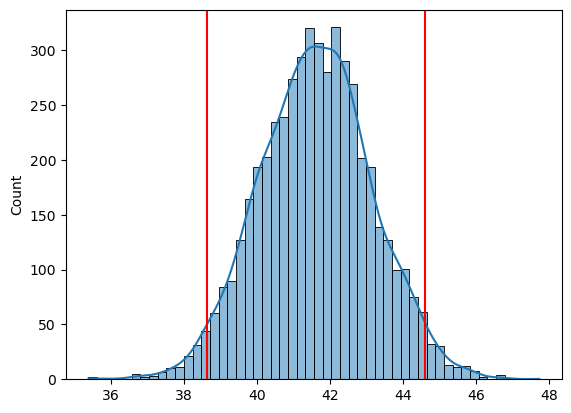

In [ ]:
sns.histplot(bootstrap_means, kde=True)
plt.axvline(ci_lower,color='r')
plt.axvline(ci_upper,color='r')


<div dir="rtl">

# کدهای بخش ۶ - آزمون فرض آماری (دو آزمون)


</div>



<div dir="rtl">

## 1.6 آزمون اول: تاثیر سن بر بستری در ICU


</div>


In [ ]:

print("--- Hypothesis Test 1: Age vs ICU ---")
# Yes = 1, No = 0
icu_ages = df[df['icu'] == 1]['age'].values
non_icu_ages = df[df['icu'] == 0]['age'].values

obs_diff_1 = np.mean(icu_ages) - np.mean(non_icu_ages)
print(f"Observed Mean Difference: {obs_diff_1:.2f} years")

# Permutation Test
all_ages = np.concatenate([icu_ages, non_icu_ages])
n_icu = len(icu_ages)
perm_diffs_1 = []

for _ in range(3000): # 
    np.random.shuffle(all_ages)
    perm_diffs_1.append(np.mean(all_ages[:n_icu]) - np.mean(all_ages[n_icu:]))

p_value_1 = np.sum(np.abs(perm_diffs_1) >= np.abs(obs_diff_1)) / 3000
ci_diff_1 = (np.percentile(perm_diffs_1, 2.5), np.percentile(perm_diffs_1, 97.5))

print(f"p-value: {p_value_1:.5f}")
print(f"95% CI under H0: ({ci_diff_1[0]:.2f}, {ci_diff_1[1]:.2f})\n")


--- Hypothesis Test 1: Age vs ICU ---
Observed Mean Difference: 8.33 years
p-value: 0.00000
95% CI under H0: (-0.32, 0.33)





<div dir="rtl">

## 2.6 آزمون دوم: دیابت و نرخ مرگ و میر


</div>


In [ ]:

print("--- Hypothesis Test 2: Diabetes vs Death Rate ---")
# Yes = 1, No = 0
diabetic_deaths = df[df['diabetes'] == 1]['died'].values
non_diabetic_deaths = df[df['diabetes'] == 0]['died'].values

obs_diff_2 = np.mean(diabetic_deaths) - np.mean(non_diabetic_deaths)
print(f"Observed Mortality Difference: {(obs_diff_2 * 100):.2f}%")

# Permutation Test
all_deaths = np.concatenate([diabetic_deaths, non_diabetic_deaths])
n_diabetic = len(diabetic_deaths)
perm_diffs_2 = []

for _ in range(3000):
    np.random.shuffle(all_deaths)
    perm_diffs_2.append(np.mean(all_deaths[:n_diabetic]) - np.mean(all_deaths[n_diabetic:]))

p_value_2 = np.sum(np.abs(perm_diffs_2) >= np.abs(obs_diff_2)) / 3000
ci_diff_2 = (np.percentile(perm_diffs_2, 2.5), np.percentile(perm_diffs_2, 97.5))

print(f"p-value: {p_value_2:.5f}")
print(f"95% CI under H0: ({ci_diff_2[0]:.4f}, {ci_diff_2[1]:.4f})")

--- Hypothesis Test 2: Diabetes vs Death Rate ---
Observed Mortality Difference: 14.08%
p-value: 0.00000
95% CI under H0: (-0.0019, 0.0020)
